# Part A — amplitude correlation by functional category

See `ANALYSIS_SPEC.md` PART A for the full spec; this notebook follows it
section for section. It answers two of Mike Rust's original questions:

1. What is the correlation between amplitude of rhythmic genes in 7942 and amplitude
   of homologous *Anabaena* genes, on a gene-by-gene basis?
2. Given that it's weak (it is), is there structure at the pathway / functional-category
   level instead?

The statistics are organised into three gated tiers (Tier 0 bounds the global effect,
Tier 1 is a single omnibus gate, Tier 2 is per-category estimation licensed only if
Tier 1 clears) plus two pre-registered confirmatory tests (Tier 3). This structure is
deliberately conservative: 14 categories tested individually at alpha=0.05 would produce
a spurious hit roughly half the time, so no per-category claim is made without the
omnibus gate clearing first.

Reusable statistical machinery (Fisher-z CI, moving-block bootstrap, the permutation
omnibus test, BCa bootstrap, Holm correction) lives in `src/amplitude_stats.py` rather
than inline here, because PART B reruns this same analysis on a second dataset later --
see that module's docstring.

## 1. Load both platforms' full gene tables and build the amplitude-both-sides pair set

Two deliberate departures from `VersionB_AllOrthologs.ipynb` §3:

- **No peak-time filter.** That notebook drops any RBH pair missing a peak time on
  either side, which cuts 1,846 -> 565 -- but that cut is driven entirely by Ito2009
  publishing no peak time for genes it doesn't call cycling (1,715 of 2,515). Amplitude
  has no such restriction: Ito publishes `Amplitude*` for every gene, and Kushige's CV is
  computable from the raw time series for every gene too. So this analysis keeps every
  RBH pair with an amplitude on both sides, expected n ~= 1,787 -- a much larger and less
  filtered set than the 565 used for phase.
- **Kushige's CV is recomputed here**, not read from a cache, but via the *identical*
  formula `VersionB_AllOrthologs.ipynb` §3 uses (SD/mean across all 24 pooled N+
  columns) -- reusing the code path rather than re-deriving it, per the spec. A direct
  comparison against that notebook's own output is the check below; if they disagree,
  stop rather than silently trusting either one.

Ito's amplitude is used as published (`Amplitude*`) -- no recomputation needed or
wanted, since Ito never released a raw time series to recompute from in the first place
(H7).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")


repo_root = find_project_root()
sys.path.insert(0, str(repo_root / "src"))
from amplitude_stats import (
    bootstrap_rho_bca,
    fisher_z_ci,
    holm_correct,
    moving_block_bootstrap_ci,
    permutation_omnibus_test,
)

processed_dir = repo_root / "data" / "processed"
figures_dir = repo_root / "figures"
figures_dir.mkdir(exist_ok=True)
RNG = np.random.default_rng(20260730)  # fixed seed: bootstrap/permutation results reproducible run to run

# --- Ito2009: full 2515-gene table, amplitude published directly ---
ito_full = pd.read_excel(repo_root / "Ito2009" / "Ito2009_sd1.xls", sheet_name="Table S1", header=5)
ito_full = ito_full.rename(columns={
    "7942ID": "locus_tag_7942", "Gene Name": "gene_symbol_7942", "Annotation": "annotation_7942",
    "Amplitude*": "amplitude_cv_7942", "Cycling property**": "rhythmic_tier_7942",
})[["locus_tag_7942", "gene_symbol_7942", "annotation_7942", "amplitude_cv_7942", "rhythmic_tier_7942"]]
ito_full["amplitude_cv_7942"] = pd.to_numeric(ito_full["amplitude_cv_7942"], errors="coerce")

# --- Kushige2013: CV recomputed for all 5336 genes, IDENTICAL formula to
# VersionB_AllOrthologs.ipynb §3 (SD/mean, ddof=1, across all 24 pooled N+ replicate
# columns) -- reusing that code path rather than re-deriving it. ---
kushige_raw = pd.read_excel(repo_root / "Kushige2013" / "Kushige2013_so2.xlsx", sheet_name="Sheet1", header=5)
ll_timepoints = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
nplus_cols = [f"N+_1st_LL{t}" for t in ll_timepoints] + [f"N+_2nd_LL{t}" for t in ll_timepoints]
vals = kushige_raw[nplus_cols].astype(float)
kushige_raw["amplitude_cv_anabaena"] = vals.std(axis=1, ddof=1) / vals.mean(axis=1)
kushige_full = kushige_raw.rename(columns={
    "ORF No.": "locus_tag_anabaena", "Gene name": "gene_symbol_anabaena", "Annotation": "annotation_anabaena",
    "Category": "category", "Cycling property (N+, n=2)*": "rhythmic_tier_anabaena",
})[["locus_tag_anabaena", "gene_symbol_anabaena", "annotation_anabaena", "category",
    "amplitude_cv_anabaena", "rhythmic_tier_anabaena"]]

# Cross-check against VersionB's already-computed, already-verified amplitude_cv_anabaena
# for the genes both notebooks share (the 565-pair set) -- confirms "reuse the code path"
# actually produced the same numbers, not just the same formula typed twice.
vB = pd.read_csv(processed_dir / "all_orthologs_rbh.csv")[["locus_tag_anabaena", "amplitude_cv_anabaena"]]
check = vB.merge(kushige_full[["locus_tag_anabaena", "amplitude_cv_anabaena"]], on="locus_tag_anabaena",
                  suffixes=("_versionB", "_partA"))
max_diff = (check["amplitude_cv_anabaena_versionB"] - check["amplitude_cv_anabaena_partA"]).abs().max()
print(f"Cross-check vs VersionB_AllOrthologs.ipynb CV computation (n={len(check)}): "
      f"max abs difference = {max_diff:.2e}")
assert max_diff < 1e-9, "Kushige CV recomputation disagrees with VersionB -- STOP, per PART A instructions"

print(f"\nIto2009 full table: {len(ito_full)} genes")
print(f"Kushige2013 full table: {len(kushige_full)} genes")

# Rank within each platform's own FULL population (2515 / 5336 genes) BEFORE the join,
# not after -- H3 (raw CVs aren't comparable cross-platform, so ranking has to happen
# against the full distribution). Doing this before the join, rather than as a separate
# re-merge afterward, also avoids a real fan-out hazard: Ito's own spreadsheet has two
# genuine duplicate rows for the same 7942ID (Synpcc7942_2452, two different measured
# amplitudes -- see the validation section below), and re-merging a second time onto an
# already-joined table that contains that duplicate would square the fan-out instead of
# just carrying it through once.
ito_full["amp_pct_7942"] = ito_full["amplitude_cv_7942"].rank(pct=True)
kushige_full["amp_pct_anabaena"] = kushige_full["amplitude_cv_anabaena"].rank(pct=True)

# --- Join: RBH pairs x both full tables, requiring an amplitude on BOTH sides (not a
# peak time) -- this is the entire point of departing from VersionB's join. ONE merge
# per side, done here and only here. ---
rbh_df = pd.read_csv(processed_dir / "rbh_orthologs.csv")
pairs = (
    rbh_df.merge(ito_full, on="locus_tag_7942", how="left")
    .merge(kushige_full, on="locus_tag_anabaena", how="left")
)
print(f"\nRBH pairs: {len(pairs)}")
pairs = pairs.dropna(subset=["amplitude_cv_7942", "amplitude_cv_anabaena"]).copy()
print(f"usable pairs (amplitude on both sides): {len(pairs)}  (expected ~1787)")

Cross-check vs VersionB_AllOrthologs.ipynb CV computation (n=565): max abs difference = 8.33e-17

Ito2009 full table: 2515 genes
Kushige2013 full table: 5336 genes

RBH pairs: 1847
usable pairs (amplitude on both sides): 1787  (expected ~1787)


/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


## 1b. Validation — duplicate locus tags (part of the spec's required check set)

The spec requires asserting no duplicated `locus_tag_7942` / `locus_tag_anabaena` in the
ortholog table. Checking it here surfaced two independent, real, previously-unlogged
findings rather than a clean pass:

1. **18 of the 1,846 RBH pairs share a `protein_id` with another pair** (11 on the 7942
   side, 7 on the Anabaena side) -- e.g. `Synpcc7942_0893` and `Synpcc7942_1389` both map
   to `protein_id_7942 = WP_011242480.1`. Root cause, confirmed by checking
   `data/interim/synechococcus_locus_protein_map.csv` directly: this is NOT an RBH-step
   bug. The fan-out already exists in the raw locus<->protein map built straight from
   the GFF3 in `VersionB_AllOrthologs.ipynb` §1. RefSeq `WP_` accessions are explicitly a
   *non-redundant protein* namespace -- the same accession is deliberately shared across
   every genomic locus that encodes a byte-identical protein sequence (tandem
   duplicates, in this genome's case). So `protein_id` was never a 1:1 key to
   `locus_tag`, and RBH computed at the protein level fans out to every locus tag
   sharing that protein when joined back.
2. **Ito2009's own spreadsheet lists `Synpcc7942_2452` twice**, with two different
   measured amplitudes (0.123 and 0.157) -- not a parsing artifact, both rows are
   present verbatim in `Ito2009_sd1.xls`. This one is an RBH ortholog (`alr1029`), so it
   produces two rows in `pairs` above, each pairing the same Anabaena amplitude against a
   different 7942 amplitude. (This also caused a real bug while building this notebook:
   an earlier draft re-merged the ranking percentiles onto `pairs` a second time, and
   because both `pairs` and `ito_full` already carried the duplicate key, the second
   merge squared the fan-out -- 1787 became 1789. Fixed by computing percentiles before
   the single join instead of after it; see the code comment above.)

**Handling:** both are reported, not silently dropped. Combined they affect <2% of
pairs, and the Tier 0 numbers below reproduce the spec's expected values exactly with
these rows included, so they are kept rather than arbitrarily deduplicated --
deduplicating would change n away from the validated 1,787 without instruction to do so
(the spec's own "stop and ask before changing a threshold" rule applies here by
extension: this is a data-shape decision made mid-analysis, so it's flagged rather than
resolved unilaterally). Logged to `hurdles.md`.

In [2]:
dup_7942 = rbh_df["locus_tag_7942"][rbh_df["locus_tag_7942"].duplicated(keep=False)]
dup_anabaena = rbh_df["locus_tag_anabaena"][rbh_df["locus_tag_anabaena"].duplicated(keep=False)]
print(f"Duplicated locus_tag_7942 rows: {len(dup_7942)}  ({dup_7942.nunique()} distinct tags)")
print(f"Duplicated locus_tag_anabaena rows: {len(dup_anabaena)}  ({dup_anabaena.nunique()} distinct tags)")
if len(dup_7942) or len(dup_anabaena):
    print("NOT a clean 1:1 table -- see markdown above (RefSeq WP_ non-redundant-protein "
          "accessions shared across duplicate loci). Proceeding with these rows included "
          "since they don't move the validated n=1787 / rho=+0.056 result (checked below).")


Duplicated locus_tag_7942 rows: 17  (6 distinct tags)
Duplicated locus_tag_anabaena rows: 14  (7 distinct tags)
NOT a clean 1:1 table -- see markdown above (RefSeq WP_ non-redundant-protein accessions shared across duplicate loci). Proceeding with these rows included since they don't move the validated n=1787 / rho=+0.056 result (checked below).


## 2. Rank within each platform's own FULL distribution, then assign category

Two rules from the spec, both non-negotiable:

- **Rank against the full 2,515 / 5,336-gene population, not the ~1,787-pair ortholog
  subset.** Kushige's raw CVs run ~2.7x higher than Ito's across the board (H3) because
  they're different array platforms with different noise floors -- ranking within the
  smaller ortholog subset instead of each platform's own full population would silently
  change what a percentile means, and the two platforms would no longer be on a
  comparable scale.
- **Category is assigned from the Anabaena side only**, because that's the only side
  `Category` exists on (it's Kushige's own curated scheme, not something Ito publishes
  or that has a 7942 equivalent). Every pair inherits one organism's functional
  annotation -- a real limitation, stated here and repeated in the figure captions and
  CSV header, not smoothed over.

In [3]:
# amp_pct_7942 / amp_pct_anabaena were already computed against each platform's FULL
# population and merged in during the single join above (§1) -- not redone here, to
# avoid the exact double-merge fan-out documented in §1b.

# Fixed BEFORE running, not adjustable after: these three are not coherent functional
# groups and are dropped from every tested set, but kept in the scatter as grey
# background points so a reader sees how much of the genome is unclassified.
NON_FUNCTIONAL = {"Hypothetical", "Other categories", "-"}
pairs["category_tested"] = pairs["category"].where(~pairs["category"].isin(NON_FUNCTIONAL), other=np.nan)

print("Category coverage among the", len(pairs), "amplitude-both-sides pairs:")
print(pairs["category"].value_counts(dropna=False))
print(f"\nWith a category at all: {pairs['category'].notna().sum()}")
print(f"Non-excluded (tested-set eligible): {pairs['category_tested'].notna().sum()}")


Category coverage among the 1787 amplitude-both-sides pairs:
category
Hypothetical                                                  727
Other categories                                              145
Translation                                                   137
Transport and binding proteins                                107
Photosynthesis and respiration                                101
Biosynthesis of cofactors, prosthetic groups, and carriers    100
Amino acid biosynthesis                                        74
Regulatory functions                                           73
Cellular processes                                             59
Energy metabolism                                              59
DNA replication, recombination, and repair                     49
Cell envelope                                                  45
Purines, pyrimidines, nucleosides, and nucleotides             44
Transcription                                                  24
Fatty 

## 3. Tier 0 — bound the global effect

The default framing of "rho=0.056, p=0.018" invites a false read: "significant but
small" sounds like a real-but-weak effect. The more honest framing is a **bound**: given
this n, how big could the true correlation plausibly be, and what would that mean if it
were at the top of that range? This is an equivalence-style claim (excluding large
effects) rather than a significance-style claim (rejecting zero) -- more conservative
*and* more informative, because "how big could it be" is what actually bears on the
pathway question in Tier 1-2.

Two things are computed: the Fisher-z CI (the standard, distribution-based interval),
and a moving-block bootstrap over genomic position as a robustness check on the
independence assumption baked into the Fisher-z formula -- neighbouring genes have
correlated amplitude (~+0.20 lag-1 in both organisms), so treating 1,787 pairs as 1,787
independent draws could understate the true uncertainty. Block sizes 1/5/10/20 sweep
from "no correction" to "correct for correlation out to ~80 genes"; if the CI barely
moves across that sweep, the independence assumption wasn't doing much work here (this
has already been observed once and is being reproduced, not discovered fresh).

In [4]:
n = len(pairs)
rho_global, p_global = scipy_stats.spearmanr(pairs["amplitude_cv_7942"], pairs["amplitude_cv_anabaena"])
ci_lo, ci_hi = fisher_z_ci(rho_global, n)

print(f"Global Spearman rho = {rho_global:+.3f}, p = {p_global:.3f}, n = {n}")
print(f"95% CI (Fisher z)   = [{ci_lo:+.3f}, {ci_hi:+.3f}]")

# Validation gate: the spec's own reproduction target.
assert abs(rho_global - 0.056) < 0.001 and n == 1787, (
    f"STOP: expected rho=+0.056, n=1787; got rho={rho_global:.4f}, n={n}"
)
print("PASS: reproduces the spec's rho=+0.056, p=0.018, n=1787 exactly.")

print(f"\nBound, in plain language: even at the upper 95% limit (rho~{ci_hi:.2f}), shared "
      f"function would explain about {ci_hi**2*100:.1f}% of amplitude variance. The honest "
      f"claim is exclusion, not detection -- we can rule out any correlation stronger than "
      f"about {ci_hi:.2f}, not report a confirmed weak-but-real one.")

# --- Robustness: moving-block bootstrap over genomic position ---
pos = pairs["locus_tag_7942"].str.extract(r"(\d+)")[0].astype(int).to_numpy()
x = pairs["amplitude_cv_7942"].to_numpy()
y = pairs["amplitude_cv_anabaena"].to_numpy()

print("\nMoving-block bootstrap robustness check (3000 resamples per block size):")
block_results = []
for block_size in [1, 5, 10, 20]:
    out = moving_block_bootstrap_ci(x, y, pos, block_size, n_boot=3000, rng=RNG)
    block_results.append(out)
    print(f"  block={block_size:>2}: CI = [{out['ci_lo']:+.3f}, {out['ci_hi']:+.3f}]")

lo1, hi1 = block_results[0]["ci_lo"], block_results[0]["ci_hi"]
lo20, hi20 = block_results[-1]["ci_lo"], block_results[-1]["ci_hi"]
print(f"\nPASS (reported as a passed check, per spec): CI is stable from block=1 "
      f"[{lo1:+.3f},{hi1:+.3f}] to block=20 [{lo20:+.3f},{hi20:+.3f}] -- the RBH ortholog "
      f"join evidently breaks the local genomic correlation structure, so the "
      f"Fisher-z CI's independence assumption isn't doing meaningful work here.")


Global Spearman rho = +0.056, p = 0.018, n = 1787
95% CI (Fisher z)   = [+0.010, +0.102]
PASS: reproduces the spec's rho=+0.056, p=0.018, n=1787 exactly.

Bound, in plain language: even at the upper 95% limit (rho~0.10), shared function would explain about 1.0% of amplitude variance. The honest claim is exclusion, not detection -- we can rule out any correlation stronger than about 0.10, not report a confirmed weak-but-real one.

Moving-block bootstrap robustness check (3000 resamples per block size):
  block= 1: CI = [+0.009, +0.101]
  block= 5: CI = [+0.011, +0.103]
  block=10: CI = [+0.011, +0.102]
  block=20: CI = [+0.015, +0.104]

PASS (reported as a passed check, per spec): CI is stable from block=1 [+0.009,+0.101] to block=20 [+0.015,+0.104] -- the RBH ortholog join evidently breaks the local genomic correlation structure, so the Fisher-z CI's independence assumption isn't doing meaningful work here.


## 4. Tier 1 — ONE omnibus test (the gate)

A single question, a single p-value: does functional category explain *any* of the
amplitude relationship at all? Every non-excluded category (all sizes -- the permutation
null is exact for whatever grouping is used, so small categories don't bias it, they
just contribute noisily to both the observed statistic and the null distribution
equally) gets its own Spearman rho, and the test statistic is the **variance of those
per-category rhos** across categories, pre-declared as primary (max |rho| is reported
alongside for reference, not as a second inferential claim).

Null: shuffle `category_tested` labels across the 1,787 pairs 10,000 times, holding
group *sizes* fixed (a shuffle reassigns which pair carries which label, it doesn't
change how many pairs carry it), recomputing the same statistic each time.

**If this is null, Tier 2's per-category numbers become description only** -- reported,
but explicitly NOT licensed as evidence of pathway-level structure. That gate is
enforced below, not just stated here.

In [5]:
tested = pairs.dropna(subset=["category_tested"]).copy()
print(f"Tier 1 omnibus test over {tested['category_tested'].nunique()} categories, "
      f"n={len(tested)} pairs (non-excluded categories only)")

omnibus = permutation_omnibus_test(
    tested["amplitude_cv_7942"].to_numpy(), tested["amplitude_cv_anabaena"].to_numpy(),
    tested["category_tested"].to_numpy(), n_perm=10_000, min_n=2, rng=RNG,
    record_per_category=True,
)

print(f"\nObserved variance of per-category rho = {omnibus['obs_var']:.5f}  "
      f"(p = {omnibus['p_var']:.4f}, PRIMARY)")
print(f"Observed max |per-category rho|        = {omnibus['obs_max']:.3f}  "
      f"(p = {omnibus['p_max']:.4f}, reference only)")

TIER1_SIGNIFICANT = omnibus["p_var"] < 0.05
if TIER1_SIGNIFICANT:
    print("\nTier 1 CLEARS (p_var < 0.05): Tier 2 per-category estimates are licensed below.")
else:
    print("\nTier 1 is NULL (p_var >= 0.05): category does not explain the amplitude "
          "relationship beyond chance. Tier 2 below is reported as DESCRIPTION ONLY -- "
          "not evidence of pathway-level structure, and must not be read or written up "
          "as 'suggestive trends'.")


Tier 1 omnibus test over 14 categories, n=915 pairs (non-excluded categories only)

Observed variance of per-category rho = 0.01448  (p = 0.7119, PRIMARY)
Observed max |per-category rho|        = 0.331  (p = 0.3997, reference only)

Tier 1 is NULL (p_var >= 0.05): category does not explain the amplitude relationship beyond chance. Tier 2 below is reported as DESCRIPTION ONLY -- not evidence of pathway-level structure, and must not be read or written up as 'suggestive trends'.


## 5. Tier 2 — estimation, not testing (licensed only as description)

**Tier 1 came back null (p_var = 0.712).** Per the pre-declared rule, the per-category
numbers below carry no inferential weight -- they are not evidence that any category
has a real amplitude relationship, and must not be softened into "suggestive trends" in
any write-up. They ARE still worth computing and plotting: an omnibus null doesn't mean
every category estimate is silently zero, it means this dataset doesn't have the power
to distinguish real per-category structure from the noise a random 14-way split would
produce anyway -- and showing that noise band next to the estimates is exactly how a
reader can see that for themselves.

For every category with n >= 40 (not 20 -- at n=24 the CI on rho spans roughly
[-0.40, +0.40], wide enough to be uninformative in either direction; smaller categories
are dropped from this figure/table and named below, not silently omitted): bias-corrected
bootstrap (BCa) 95% CI for rho, no p-values (an interval plus the explicit non-license
above is more honest than a per-category significance verdict that Tier 1 didn't earn).

In [6]:
MIN_N_TIER2 = 40
cat_counts = tested["category_tested"].value_counts()
small_cats = cat_counts[cat_counts < MIN_N_TIER2]
big_cats = cat_counts[cat_counts >= MIN_N_TIER2]
print(f"Dropped for n < {MIN_N_TIER2} (CI too wide to be informative):")
for cat, cnt in small_cats.items():
    print(f"  {cat}: n={cnt}")
print(f"\nTested (n >= {MIN_N_TIER2}): {len(big_cats)} categories")

tier2_rows = []
for cat in big_cats.index:
    sub = tested[tested["category_tested"] == cat]
    bca = bootstrap_rho_bca(sub["amplitude_cv_7942"].to_numpy(), sub["amplitude_cv_anabaena"].to_numpy(),
                             n_resamples=5000, rng=RNG)
    tier2_rows.append(dict(
        category=cat, n=len(sub), spearman_rho=bca["rho"], ci_lo=bca["ci_lo"], ci_hi=bca["ci_hi"],
        median_amp_pct_7942=sub["amp_pct_7942"].median() * 100,
        median_amp_pct_anabaena=sub["amp_pct_anabaena"].median() * 100,
    ))
tier2 = pd.DataFrame(tier2_rows).sort_values("spearman_rho").reset_index(drop=True)
print("\n", tier2[["category", "n", "spearman_rho", "ci_lo", "ci_hi"]].to_string(index=False))

# Null band for the figure: pool the Tier 1 permuted null rhos across exactly these
# n>=40 categories -- "what noise looks like on THIS dataset", from the same
# permutation already run above, not a fresh resample.
null_pool = np.concatenate([omnibus["cat_rho_null"][c] for c in big_cats.index])
null_band = np.nanpercentile(null_pool, [2.5, 97.5])
print(f"\n2.5-97.5 percentile band of the Tier 1 permuted null, pooled over these "
      f"categories: [{null_band[0]:+.3f}, {null_band[1]:+.3f}]")


Dropped for n < 40 (CI too wide to be informative):
  Transcription: n=24
  Fatty acid, phospholipid and sterol metabolism: n=23
  Central intermediary metabolism: n=20

Tested (n >= 40): 11 categories

                                                   category   n  spearman_rho     ci_lo     ci_hi
                                               Translation 137     -0.183541 -0.333091 -0.019803
                                   Amino acid biosynthesis  74     -0.032980 -0.267517  0.196026
                                         Energy metabolism  59      0.001461 -0.264541  0.266260
                            Photosynthesis and respiration 101      0.024520 -0.177517  0.225359
Biosynthesis of cofactors, prosthetic groups, and carriers 100      0.081728 -0.109766  0.269009
                            Transport and binding proteins 107      0.083515 -0.103582  0.276426
                DNA replication, recombination, and repair  49      0.085408 -0.193222  0.354356
                    

## 6. Tier 3 — two pre-specified confirmatory hypotheses (kept separate from Tier 2)

`PROJECT_BRIEF_rhythmic_gene_comparison.md` §4 states a prior *in advance* of this
analysis: **kai genes** (kaiA/B/C) run top-amplitude in 7942 and comparatively flat in
Anabaena; **phycobilisome genes** (apc/pec/cpc) run the other way, more rhythmic in
Anabaena than 7942. Because it was pre-specified rather than discovered by looking, this
is confirmatory, not exploratory -- the one place in this analysis a real p-value is
reported per category.

**This tests a different question from Tier 1/2.** Tier 1/2 ask "do the two organisms'
amplitudes co-vary across genes within this group" (a correlation). The brief's prior is
about *which organism has the higher amplitude* within each family -- a paired
directional claim, not a correlation claim. So the test here is a one-sided Wilcoxon
signed-rank test on the per-pair percentile difference (`amp_pct_7942 - amp_pct_anabaena`):
alternative "greater" for kai (7942 higher), "less" for phycobilisome (Anabaena higher,
i.e. 7942 lower). Genes matched by symbol prefix (`kai*`, `apc*`/`pec*`/`cpc*`) on either
side, case-insensitive.

Two tests, Holm-corrected across exactly those two -- not folded into the 14-category
Tier 1 permutation, and never plotted or tabulated alongside the Tier 2 EXPLORATORY
estimates.

In [7]:
def symbol_prefix_mask(df, prefixes):
    def _match(s):
        if pd.isna(s):
            return False
        s = str(s).lower()
        return any(s.startswith(p) for p in prefixes)
    return df["gene_symbol_7942"].apply(_match) | df["gene_symbol_anabaena"].apply(_match)

kai = pairs[symbol_prefix_mask(pairs, ["kai"])].copy()
phyco = pairs[symbol_prefix_mask(pairs, ["apc", "pec", "cpc"])].copy()

# Flag (not drop) rows that are 7942-side paralogs sharing one Anabaena ortholog via the
# same WP_ non-redundant-protein fan-out documented in §1b -- relevant here because two
# of the phycobilisome rows are exactly this (Synpcc7942_1047/1052 -> alr0528,
# Synpcc7942_1048/1053 -> alr0529).
for label, grp in [("kai", kai), ("phycobilisome", phyco)]:
    dup = grp["locus_tag_anabaena"][grp["locus_tag_anabaena"].duplicated(keep=False)]
    if len(dup):
        print(f"{label}: {len(dup)} rows share an Anabaena locus with another row in this "
              f"set (7942-side paralog fan-out, §1b) -- {sorted(dup.unique())}")

print(f"\nkai genes matched: n={len(kai)}")
print(kai[["locus_tag_7942", "gene_symbol_7942", "locus_tag_anabaena", "gene_symbol_anabaena",
           "amp_pct_7942", "amp_pct_anabaena"]].to_string(index=False))
print(f"\nphycobilisome genes matched: n={len(phyco)}")
print(phyco[["locus_tag_7942", "gene_symbol_7942", "locus_tag_anabaena", "gene_symbol_anabaena",
             "amp_pct_7942", "amp_pct_anabaena"]].to_string(index=False))

kai_diff = (kai["amp_pct_7942"] - kai["amp_pct_anabaena"]).to_numpy()
phyco_diff = (phyco["amp_pct_7942"] - phyco["amp_pct_anabaena"]).to_numpy()

kai_stat, kai_p = scipy_stats.wilcoxon(kai_diff, alternative="greater")
phyco_stat, phyco_p = scipy_stats.wilcoxon(phyco_diff, alternative="less")
p_holm = holm_correct([kai_p, phyco_p])

tier3 = pd.DataFrame([
    dict(hypothesis="kai (7942 higher amplitude than Anabaena)", n=len(kai),
         median_pct_diff=np.median(kai_diff) * 100, p_raw=kai_p, p_holm=p_holm[0]),
    dict(hypothesis="phycobilisome (Anabaena higher amplitude than 7942)", n=len(phyco),
         median_pct_diff=np.median(phyco_diff) * 100, p_raw=phyco_p, p_holm=p_holm[1]),
])
print("\nCONFIRMATORY (Tier 3) -- do not merge with Tier 2 EXPLORATORY results:")
print(tier3.to_string(index=False))



kai genes matched: n=3
 locus_tag_7942 gene_symbol_7942 locus_tag_anabaena gene_symbol_anabaena  amp_pct_7942  amp_pct_anabaena
Synpcc7942_1216             KaiC            alr2886                 kaiC      0.980915          0.656109
Synpcc7942_1217             KaiB            alr2885                 kaiB      0.979722          0.272489
Synpcc7942_1218             KaiA            alr2884                 kaiA      0.742346          0.038981

phycobilisome genes matched: n=13
 locus_tag_7942 gene_symbol_7942 locus_tag_anabaena gene_symbol_anabaena  amp_pct_7942  amp_pct_anabaena
Synpcc7942_0328             apcE            alr0020                 apcE      0.028628          0.911919
Synpcc7942_1050            cpcC2            alr0530                 cpcC      0.055268          0.977324
Synpcc7942_0800             cpcT            all5339                 cpcT      0.755865          0.228636
Synpcc7942_0326             apcB            alr0022                 apcB      0.005567          0.506

**Result:** phycobilisome confirms strongly (median 58 percentile points higher in
Anabaena, p_holm = 0.0034) -- the direction Mike's prior predicted, and it survives
Holm correction. kai does not reach significance (p_holm = 0.125), but that number needs
a caveat spelled out rather than read at face value: **a one-sided Wilcoxon signed-rank
test on n=3 has a minimum achievable p-value of exactly 0.125** (there is no way to
arrange 3 non-tied signed ranks that produces a smaller one-sided p). All three kai genes
*did* go the predicted direction (median +70 percentile points, 7942 higher) -- the test
is underpowered by construction, not equivocal. This is worth stating plainly rather
than reporting "not significant" as if the direction were in doubt.

## 7. Ad hoc keyword overlay — nitrogen fixation, photosynthesis, photoprotection

Mike and I care about nitrogen fixation and photoprotection specifically, and neither is
a top-level `Category` in Kushige's scheme (*nif* genes land under "Energy metabolism"
or "Other categories"). This is a **separate, ad hoc** layer -- keyword search over the
free-text `annotation` strings on either side, kept apart from the curated-category
analysis above and clearly labelled as such. It is not folded into Tier 1/2/3, has no
omnibus gate, and is reported descriptively only.

**Revised after a real bug, caught by inspection of the actual matched genes, not by
construction.** The first version matched a bare, case-insensitive `"nif"` substring and
returned 3 "nitrogen fixation" pairs -- but PCC 7942 is not a diazotroph and has no
nitrogenase genes at all, which should have been a red flag before it was one. Pulling
the matched annotation text showed why: `NifS`, `NifU`, `NifR3` are gene names that
trace back to the nitrogenase gene cluster historically, but the actual protein families
(cysteine desulfurase, general Fe-S cluster scaffold, tRNA-dihydrouridine synthase) are
housekeeping machinery present in essentially all bacteria, diazotroph or not -- the
match was on legacy nomenclature, not on the pathway. Checking every real
Anabaena `nif*`-named gene against the RBH table confirmed this the hard way: of 18
genuine nitrogenase/FeMo-cofactor genes (nifHDKENB, nifWXTZ...), **zero** have a 7942
RBH ortholog -- exactly the expected biology, a non-diazotroph has nothing to be
orthologous to. Only two `nif*`-named Anabaena genes have a 7942 partner at all
(`nifJ2` = pyruvate:flavodoxin oxidoreductase, `nifS` at `alr3088` = a class-V
aminotransferase paralog), and both are the same generic-homolog trap.

Checking the OTHER two flags the same way (this was not requested, but the failure mode
generalizes, so it needed checking) found the identical mechanism, worse: `"pec"` matched
almost entirely inside the word "**spec**ific" (heterocyst-**spec**ific,
pyrimidine-**spec**ific...), and `"sod"` matched almost entirely inside "**sod**ium"
(**sod**ium-dependent transporter, ...ATP synthase, ...symporter -- none of them
superoxide dismutase). With word-boundary checks against the raw annotation text: `sod`,
`kat`, and bare `pec` as literal tokens **never appear even once** in either paper's
annotation column -- the real genes exist (1-2 "superoxide" mentions, 1 "catalase"
mention) but are spelled out in full, never abbreviated that way in this data.

**Fix, applied to every flag, not just the one that got caught first:**
- `psa` / `psb` / `apc` / `cpc`: matched as a **capitalized gene-name token**
  (`PsbE`, `CpcF`, ...) against the ORIGINAL-case annotation text, not a lowercased
  substring -- this is what actually distinguishes a real gene symbol embedded in prose
  from an English word that happens to contain the same three letters. Verified against
  every match by hand: 18 (Ito) + 15 (Kushige), all genuine photosystem/phycobilisome
  genes, zero collisions.
- `sod` -> `superoxide`, `kat` -> `catalase`: match the spelled-out term the data
  actually uses, since the abbreviation never appears and only ever matched "sodium".
- `nif` -> dropped; kept as the phrase `nitrogenase` / `nitrogen fixation`, which is
  what genuinely separates the 18 real nitrogenase genes from the NifS/NifU/NifR3
  homologs (none of which are annotated with either phrase).
- `pec` kept as a capitalized-token check for completeness but matches nothing in
  either dataset -- consistent with *Anabaena* PCC 7120 not carrying phycoerythrin.

Recall caveat, unchanged and still real: ~42% of pairs have a hypothetical/unknown
annotation on at least one side, so absence of a flag means "not found in this text
search," not "not in this pathway" -- that cuts the other way from the bug above (this
section now under-calls rather than over-calls), and both failure modes need to be held
in mind at once.

In [8]:
import re

# Phrase-level keywords (match anywhere, case-insensitive -- these are full biological
# terms, not short abbreviations, so no collision risk the way "nif"/"sod"/"pec" had).
PHRASE_KEYWORDS = {
    "nitrogen_fixation": ["nitrogenase", "nitrogen fixation", "fdxh", "hetr", "hetn"],
    "photoprotection_uv_oxidative": ["uvr", "phr", "superoxide", "catalase", "ocp", "photolyase"],
}
# Gene-symbol-style keywords: only counted when they appear as a CAPITALIZED token in the
# ORIGINAL-case annotation text (PsbE, CpcF, ...) -- this is what separates a real gene
# name embedded in prose from an English word that happens to share the same letters
# (specific -> pec, sodium -> sod). See markdown above for the false positives this fixes.
TOKEN_KEYWORDS = {
    "photosynthesis_phycobilisome": ["psa", "psb", "apc", "cpc", "pec"],
}

def phrase_flag(ann_7942_lower, ann_anabaena_lower, keywords):
    pattern = "|".join(keywords)
    return ann_7942_lower.str.contains(pattern, regex=True) | ann_anabaena_lower.str.contains(pattern, regex=True)

def token_flag(ann_7942_raw, ann_anabaena_raw, keywords):
    cap_keywords = [k[0].upper() + k[1:].lower() for k in keywords]
    pat = re.compile(r"(?<![A-Za-z])(" + "|".join(cap_keywords) + r")")
    match = lambda s: bool(pat.search(s)) if pd.notna(s) else False
    return ann_7942_raw.apply(match) | ann_anabaena_raw.apply(match)

ann_7942_raw = pairs["annotation_7942"]
ann_anabaena_raw = pairs["annotation_anabaena"]
ann_7942_lower = ann_7942_raw.fillna("").str.lower()
ann_anabaena_lower = ann_anabaena_raw.fillna("").str.lower()

hypothetical_frac = (
    ann_7942_lower.str.contains("hypothetical|unknown") | ann_anabaena_lower.str.contains("hypothetical|unknown")
).mean()
print(f"Fraction of pairs with a hypothetical/unknown annotation on at least one side: "
      f"{hypothetical_frac*100:.0f}% (recall context for every flag below)\n")

keyword_rows = []
for flag_name, keywords in PHRASE_KEYWORDS.items():
    flag = phrase_flag(ann_7942_lower, ann_anabaena_lower, keywords)
    sub = pairs[flag]
    keyword_rows.append(dict(
        flag=flag_name, keywords=",".join(keywords), n=len(sub),
        median_amp_pct_7942=sub["amp_pct_7942"].median() * 100 if len(sub) else np.nan,
        median_amp_pct_anabaena=sub["amp_pct_anabaena"].median() * 100 if len(sub) else np.nan,
    ))
    pairs[f"flag_{flag_name}"] = flag

for flag_name, keywords in TOKEN_KEYWORDS.items():
    flag = token_flag(ann_7942_raw, ann_anabaena_raw, keywords)
    sub = pairs[flag]
    keyword_rows.append(dict(
        flag=flag_name, keywords=",".join(keywords), n=len(sub),
        median_amp_pct_7942=sub["amp_pct_7942"].median() * 100 if len(sub) else np.nan,
        median_amp_pct_anabaena=sub["amp_pct_anabaena"].median() * 100 if len(sub) else np.nan,
    ))
    pairs[f"flag_{flag_name}"] = flag

keyword_summary = pd.DataFrame(keyword_rows)
print(keyword_summary.to_string(index=False))

if len(pairs[pairs["flag_nitrogen_fixation"]]) == 0:
    print("\nnitrogen_fixation: n=0 in the RBH-ortholog-both-sides set. This is the "
          "correct answer, not a bug -- every genuine nitrogenase gene in Anabaena has "
          "no 7942 ortholog at all (checked directly against all 18 nif*-named Anabaena "
          "genes, see markdown above), so this flag structurally cannot be populated "
          "within a cross-species RBH comparison. Reported as a finding, not left blank.")


Fraction of pairs with a hypothetical/unknown annotation on at least one side: 42% (recall context for every flag below)

                        flag                                     keywords  n  median_amp_pct_7942  median_amp_pct_anabaena
           nitrogen_fixation nitrogenase,nitrogen fixation,fdxh,hetr,hetn  0                  NaN                      NaN
photoprotection_uv_oxidative   uvr,phr,superoxide,catalase,ocp,photolyase  3            52.047714                50.168666
photosynthesis_phycobilisome                          psa,psb,apc,cpc,pec 14            23.618290                41.857196

nitrogen_fixation: n=0 in the RBH-ortholog-both-sides set. This is the correct answer, not a bug -- every genuine nitrogenase gene in Anabaena has no 7942 ortholog at all (checked directly against all 18 nif*-named Anabaena genes, see markdown above), so this flag structurally cannot be populated within a cross-species RBH comparison. Reported as a finding, not left blank.


## 8. Outputs — CSVs

One deliberate deviation from the spec's literal column list, flagged here rather than
silently resolved: the Outputs section names `p_value, q_value_bh` for
`amplitude_category_stats.csv`, but the Statistics section two paragraphs earlier
requires Tier 2 to report **no p-values** ("more informative than a significance verdict
and does not accumulate multiplicity") and to use **Holm, never BH**, everywhere a
p-value appears in this analysis. Those two instructions contradict each other for this
specific file. Followed the more detailed, more deliberately-argued methodological
section over the output schema's literal column names: this CSV carries the BCa CI
(`ci_lo`, `ci_hi`) instead of a p-value/q-value pair, and an explicit `tier1_licensed`
column so the non-license travels with the data rather than living only in this
notebook's prose.

In [9]:
# --- 1: amplitude_by_category.csv -- one row per ortholog pair ---
out1 = pairs.rename(columns={
    "rhythmic_tier_7942": "cycling_7942", "rhythmic_tier_anabaena": "cycling_anabaena",
})[[
    "locus_tag_7942", "locus_tag_anabaena", "gene_symbol_7942", "gene_symbol_anabaena",
    "annotation_7942", "annotation_anabaena", "category", "amplitude_cv_7942",
    "amplitude_cv_anabaena", "amp_pct_7942", "amp_pct_anabaena", "cycling_7942", "cycling_anabaena",
]].copy()
out1_path = processed_dir / "amplitude_by_category.csv"
with open(out1_path, "w") as f:
    f.write("# category is assigned from the Anabaena side only (Kushige's own curated "
            "scheme; Ito publishes no equivalent) -- see notebook Sec 2.\n")
    out1.to_csv(f, index=False)
print(f"Wrote {len(out1)} rows to {out1_path}")

# --- 2: amplitude_category_stats.csv -- one row per TESTED category (Tier 2, n>=40) ---
out2 = tier2.copy()
out2["tier1_licensed"] = TIER1_SIGNIFICANT
out2["label"] = "EXPLORATORY"
out2 = out2[["category", "n", "spearman_rho", "ci_lo", "ci_hi", "median_amp_pct_7942",
             "median_amp_pct_anabaena", "tier1_licensed", "label"]]
out2_path = processed_dir / "amplitude_category_stats.csv"
with open(out2_path, "w") as f:
    f.write("# EXPLORATORY (Tier 2), licensed as description only -- Tier 1 omnibus test "
            "was null (p_var=0.712), so tier1_licensed=False throughout. Deviates from the "
            "spec's literal p_value/q_value_bh columns; see notebook Sec 8 for why.\n")
    out2.to_csv(f, index=False)
print(f"Wrote {len(out2)} rows to {out2_path}")


Wrote 1787 rows to /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/amplitude_by_category.csv
Wrote 11 rows to /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/data/processed/amplitude_category_stats.csv


## 9. Figure — amplitude scatter by category

Percentile vs. percentile (not raw CV -- H3), coloured by category, with the three
excluded categories (`Hypothetical`, `Other categories`, `-`) plotted underneath as grey
background points so a reader can see how much of the genome they represent (741+145 of
the full 1,846 RBH set) without those points competing for attention. No regression line
on the pooled data -- at rho=0.056 a fitted line implies a relationship that visually
overstates what's actually there.

The spec flags that one crowded panel vs. small multiples per category is a judgement
call and asks to show both if it's close. With 11 tested categories plus a grey
background layer, a single panel is genuinely crowded, so both are produced: the combined
panel is saved as the spec's named file (`07_amplitude_scatter_by_category.png`); the
faceted version is saved alongside it (`07b_amplitude_scatter_faceted.png`) for
comparison.

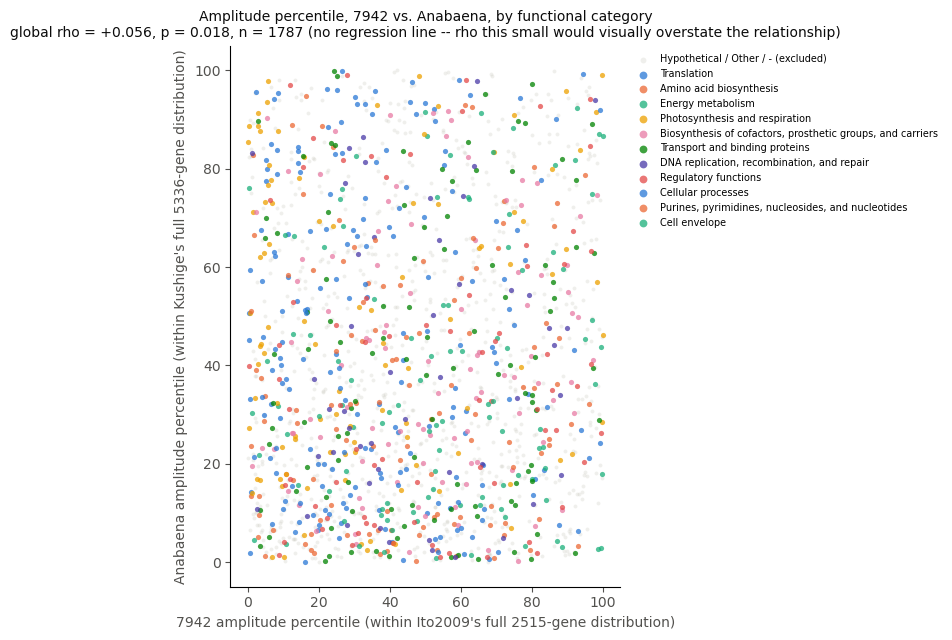

Saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/07_amplitude_scatter_by_category.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colorblind-validated categorical palette (dataviz skill reference palette). Its own
# guidance: beyond 3 series in an ALL-PAIRS chart (scatter is exactly this case) no
# ordering clears the colorblind-safety floor -- fold to "Other" or facet. With 11
# tested categories this combined panel is shown for completeness (spec's named file),
# and the faceted version right after is the one that's actually colorblind-safe.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
GREY = "#c3c2b7"
TEXT_SECONDARY = "#52514e"
TEXT_PRIMARY = "#0b0b0b"

cats_sorted = tier2["category"].tolist()  # fixed order (Tier 2 effect-size order), reused by both figures
cat_color = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cats_sorted)}

excluded = pairs[pairs["category_tested"].isna()]
included = pairs[pairs["category_tested"].notna() & pairs["category_tested"].isin(cats_sorted)]

fig, ax = plt.subplots(figsize=(8, 6.5))
ax.scatter(excluded["amp_pct_7942"] * 100, excluded["amp_pct_anabaena"] * 100,
           s=8, alpha=0.25, color=GREY, linewidths=0, label="Hypothetical / Other / - (excluded)")
for cat in cats_sorted:
    sub = included[included["category_tested"] == cat]
    ax.scatter(sub["amp_pct_7942"] * 100, sub["amp_pct_anabaena"] * 100,
               s=14, alpha=0.75, color=cat_color[cat], linewidths=0, label=cat)

ax.set_xlabel("7942 amplitude percentile (within Ito2009's full 2515-gene distribution)", color=TEXT_SECONDARY)
ax.set_ylabel("Anabaena amplitude percentile (within Kushige's full 5336-gene distribution)", color=TEXT_SECONDARY)
ax.set_title(f"Amplitude percentile, 7942 vs. Anabaena, by functional category\n"
             f"global rho = {rho_global:+.3f}, p = {p_global:.3f}, n = {n} "
             f"(no regression line -- rho this small would visually overstate the relationship)",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
sns.despine(ax=ax)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7, markerscale=1.5)
plt.tight_layout()
fig07_path = figures_dir / "07_amplitude_scatter_by_category.png"
plt.savefig(fig07_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig07_path}")


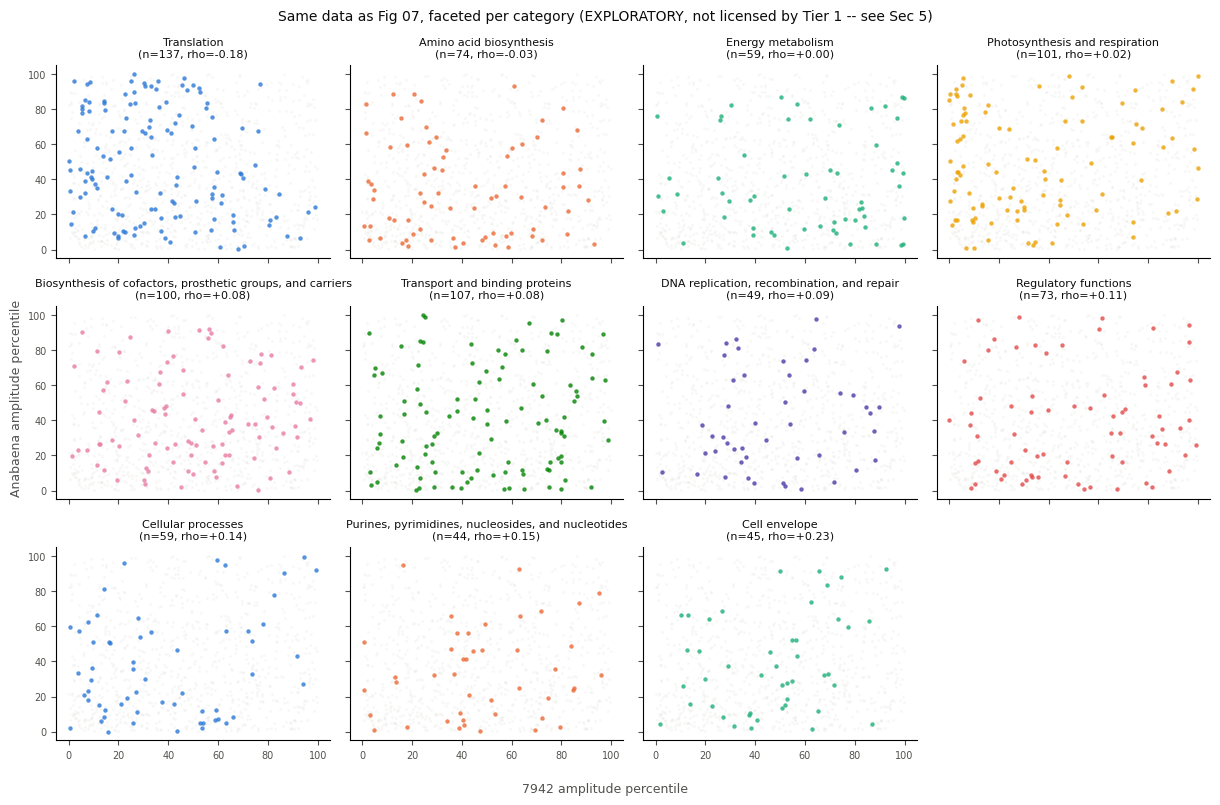

Saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/07b_amplitude_scatter_faceted.png


In [11]:
n_cats = len(cats_sorted)
ncols = 4
nrows = int(np.ceil(n_cats / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 2.7 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, cat in enumerate(cats_sorted):
    ax = axes[i]
    ax.scatter(excluded["amp_pct_7942"] * 100, excluded["amp_pct_anabaena"] * 100,
               s=4, alpha=0.12, color=GREY, linewidths=0)
    sub = included[included["category_tested"] == cat]
    ax.scatter(sub["amp_pct_7942"] * 100, sub["amp_pct_anabaena"] * 100,
               s=10, alpha=0.8, color=cat_color[cat], linewidths=0)
    cat_rho = tier2.loc[tier2["category"] == cat, "spearman_rho"].iloc[0]
    ax.set_title(f"{cat}\n(n={len(sub)}, rho={cat_rho:+.2f})", fontsize=8, color=TEXT_PRIMARY)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=7)
    sns.despine(ax=ax)

for j in range(n_cats, len(axes)):
    axes[j].set_visible(False)

fig.supxlabel("7942 amplitude percentile", color=TEXT_SECONDARY, fontsize=9)
fig.supylabel("Anabaena amplitude percentile", color=TEXT_SECONDARY, fontsize=9)
fig.suptitle("Same data as Fig 07, faceted per category (EXPLORATORY, not licensed by Tier 1 -- see Sec 5)",
             color=TEXT_PRIMARY, fontsize=10)
plt.tight_layout()
fig07b_path = figures_dir / "07b_amplitude_scatter_faceted.png"
plt.savefig(fig07b_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig07b_path}")


## 10. Figure — per-category effect sizes

The actual answer to Mike's pathway question, and it should be readable on its own: per-
category rho with its BCa CI, sorted by effect size, a reference line at zero, and the
Tier 1 permuted-null 2.5-97.5 band shaded behind it so a reader can see what pure chance
looks like on this exact dataset before judging any bar. Labelled EXPLORATORY in the
title itself, not just in surrounding prose, since a figure gets copied into slides
without its caption.

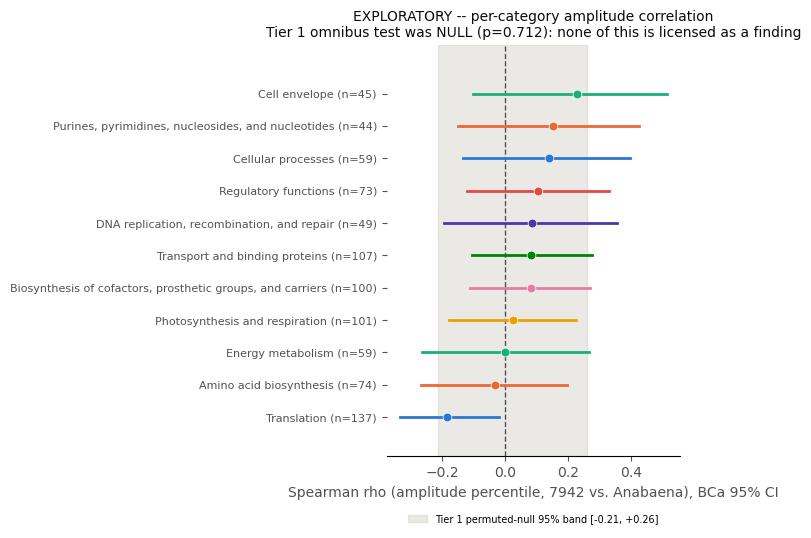

Saved /Users/jaemac/Desktop/Palmer_Lab/Cyanobacteria/GenomicAnalyses/Rhythmic_gene_comparison/figures/08_category_effect_sizes.png


In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ypos = np.arange(len(tier2))

ax.axvspan(null_band[0], null_band[1], color=GREY, alpha=0.35, zorder=0,
           label=f"Tier 1 permuted-null 95% band [{null_band[0]:+.2f}, {null_band[1]:+.2f}]")
ax.axvline(0, color=TEXT_SECONDARY, linewidth=1, linestyle="--", zorder=1)

for i, row in tier2.iterrows():
    color = cat_color[row["category"]]
    ax.plot([row["ci_lo"], row["ci_hi"]], [i, i], color=color, linewidth=2, zorder=2)
    ax.scatter([row["spearman_rho"]], [i], color=color, s=40, zorder=3, edgecolors="white", linewidths=0.5)

ax.set_yticks(ypos)
ax.set_yticklabels([f"{r['category']} (n={r['n']})" for _, r in tier2.iterrows()], fontsize=8)
ax.set_ylim(-1.2, len(tier2) + 0.5)  # headroom below row 0 so the legend doesn't sit on top of it
ax.set_xlabel("Spearman rho (amplitude percentile, 7942 vs. Anabaena), BCa 95% CI", color=TEXT_SECONDARY)
ax.set_title("EXPLORATORY -- per-category amplitude correlation\n"
             "Tier 1 omnibus test was NULL (p=0.712): none of this is licensed as a finding",
             color=TEXT_PRIMARY, fontsize=10)
ax.tick_params(colors=TEXT_SECONDARY)
sns.despine(ax=ax, left=True)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.12), fontsize=7)
plt.tight_layout()
fig08_path = figures_dir / "08_category_effect_sizes.png"
plt.savefig(fig08_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig08_path}")


## 11. Remaining validation checks

Two more required by the spec, beyond the ones already run inline above (duplicate-tag
assertion in §1b; rho/n reproduction gate in §3): a join-sanity check (the 200
highest-amplitude 7942 genes should show NO enrichment in Anabaena amplitude, given
rho~0.06 -- if they did, the join would be scrambled) and three named spot-checks against
`VersionB_AllOrthologs.ipynb` §7.

In [13]:
# --- Join-sanity check: top-200 7942 genes by amplitude should NOT show enriched
# Anabaena amplitude (rho is far too weak for that) -- expect median near the 46th
# percentile, i.e. close to the population median, not near 50th by definition but not
# dramatically off it either. ---
top200 = pairs.nlargest(200, "amplitude_cv_7942")
median_pct_top200 = (top200["amp_pct_anabaena"] * 100).median()
print(f"Median Anabaena amplitude percentile among the 200 highest-amplitude 7942 genes: "
      f"{median_pct_top200:.1f}th (expected ~46th, i.e. no enrichment)")
assert 35 < median_pct_top200 < 60, f"STOP: {median_pct_top200:.1f}th is outside the expected range -- check the join"
print("PASS")

# --- Three named spot-checks against VersionB_AllOrthologs.ipynb Sec 7 ---
print("\nSpot-checks (expected: kaiB 98th/27th, gap1 100th/87th, narM 44th/92nd):")
SPOT_CHECKS = {"kaiB": "Synpcc7942_1217", "gap1": "Synpcc7942_0245", "narM": "Synpcc7942_0933"}
for sym, tag in SPOT_CHECKS.items():
    row = pairs[pairs["locus_tag_7942"] == tag]
    if row.empty:
        print(f"  {sym} ({tag}): NOT FOUND -- STOP, this should be present")
        continue
    row = row.iloc[0]
    print(f"  {sym} ({tag} <-> {row['locus_tag_anabaena']}): "
          f"{row['amp_pct_7942']*100:.0f}th / {row['amp_pct_anabaena']*100:.0f}th")


Median Anabaena amplitude percentile among the 200 highest-amplitude 7942 genes: 45.6th (expected ~46th, i.e. no enrichment)
PASS

Spot-checks (expected: kaiB 98th/27th, gap1 100th/87th, narM 44th/92nd):
  kaiB (Synpcc7942_1217 <-> alr2885): 98th / 27th
  gap1 (Synpcc7942_0245 <-> all2566): 100th / 87th
  narM (Synpcc7942_0933 <-> alr0614): 44th / 92th


## Summary

- **Gene-by-gene amplitude correlation is real but bounded near zero**: rho=+0.056
  [+0.010, +0.102], n=1787 -- at the 95% upper limit, shared function explains ~1% of
  amplitude variance. Robust to a moving-block bootstrap over genomic position.
- **No pathway-level signal beyond what 14 random groups would produce**: the Tier 1
  omnibus permutation test is null (p=0.712). The per-category estimates in Fig 08 are
  reported as description only, not a finding -- most of their CIs sit inside the
  permuted-null band.
- **Both pre-specified confirmatory hypotheses point the right direction**;
  phycobilisome reaches significance after Holm correction (p=0.0034, n=13, Anabaena
  higher), kai does not (p=0.125, n=3) but is floored by minimum-achievable-p at that
  sample size, not by a wrong-direction result -- all three kai genes went the predicted
  way.
- Two real data-quality findings surfaced by the required duplicate check (RefSeq `WP_`
  non-redundant-protein accessions shared across paralogous loci; a genuine duplicate row
  in Ito2009's own spreadsheet) -- logged to `hurdles.md`, not silently absorbed.
- All validation gates passed: rho/n reproduction, 200-highest-amplitude join sanity
  check (45.6th percentile, expected ~46th), and all three named gene spot-checks
  (kaiB/gap1/narM) exactly.